Importing required libraries and models

In [1]:
import pandas as pd 
import numpy as np 
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from datetime import datetime
from pandas import Series
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore")

Importing the Dataset

In [2]:
df= pd.read_csv('/kaggle/input/delhi-weather-and-aqi-dataset-2025/delhi-weather-aqi-2025.csv')


Display the dataset

In [3]:
df

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52555,31/12/2025,19:00,IGI Airport,28.5562,77.100,15.0,88,984.3,7.5,Mainly clear,WMO Code 1,209,148.5,149.0,1517,109.6
52556,31/12/2025,20:00,IGI Airport,28.5562,77.100,14.4,90,984.7,6.6,Partly cloudy,WMO Code 2,209,153.7,154.1,1637,112.5
52557,31/12/2025,21:00,IGI Airport,28.5562,77.100,13.8,92,985.1,5.8,Partly cloudy,WMO Code 2,209,149.5,149.9,1601,100.9
52558,31/12/2025,22:00,IGI Airport,28.5562,77.100,13.4,94,985.1,6.0,Overcast,WMO Code 3,209,146.7,147.1,1476,80.2


CHecking for Columns,Datatypes and Null values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_ist        52560 non-null  object 
 1   time_ist        52560 non-null  object 
 2   location        52560 non-null  object 
 3   lat             52560 non-null  float64
 4   lon             52560 non-null  float64
 5   temp_c          52560 non-null  float64
 6   humidity        52560 non-null  int64  
 7   pressure_mb     52560 non-null  float64
 8   windspeed_kph   52560 non-null  float64
 9   condition_text  52560 non-null  object 
 10  description     52560 non-null  object 
 11  aqi_index       52560 non-null  int64  
 12  pm2_5           52560 non-null  float64
 13  pm10            52560 non-null  float64
 14  co              52560 non-null  int64  
 15  no2             52560 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 6.4+ MB


Quick maths On dataset

In [5]:
df.describe()

,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,28.608850,77.174567,25.024406,62.285940,983.162635,6.565820,287.364212,89.542432,300.462700,863.844273,35.442757
std,0.058927,0.096519,7.618231,23.454666,6.688582,3.478066,327.979524,55.363812,412.782899,600.845140,28.978905
min,28.527300,77.049400,5.700000,5.000000,966.100000,0.000000,56.000000,6.000000,6.100000,146.000000,1.700000
25%,28.556200,77.100000,19.500000,44.000000,977.500000,4.000000,152.000000,51.100000,80.600000,464.000000,14.900000
50%,28.609300,77.160100,26.500000,65.000000,983.400000,6.000000,170.000000,76.400000,151.800000,664.000000,26.900000
75%,28.646900,77.261800,30.500000,82.000000,988.900000,8.700000,238.000000,110.400000,325.000000,1078.000000,47.100000
max,28.704100,77.316000,43.800000,100.000000,998.800000,27.100000,2742.000000,443.300000,3263.400000,7432.000000,220.100000


Droping duplicates if there any.

In [6]:
df.drop_duplicates()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52555,31/12/2025,19:00,IGI Airport,28.5562,77.100,15.0,88,984.3,7.5,Mainly clear,WMO Code 1,209,148.5,149.0,1517,109.6
52556,31/12/2025,20:00,IGI Airport,28.5562,77.100,14.4,90,984.7,6.6,Partly cloudy,WMO Code 2,209,153.7,154.1,1637,112.5
52557,31/12/2025,21:00,IGI Airport,28.5562,77.100,13.8,92,985.1,5.8,Partly cloudy,WMO Code 2,209,149.5,149.9,1601,100.9
52558,31/12/2025,22:00,IGI Airport,28.5562,77.100,13.4,94,985.1,6.0,Overcast,WMO Code 3,209,146.7,147.1,1476,80.2


Visual Analysis of dataset

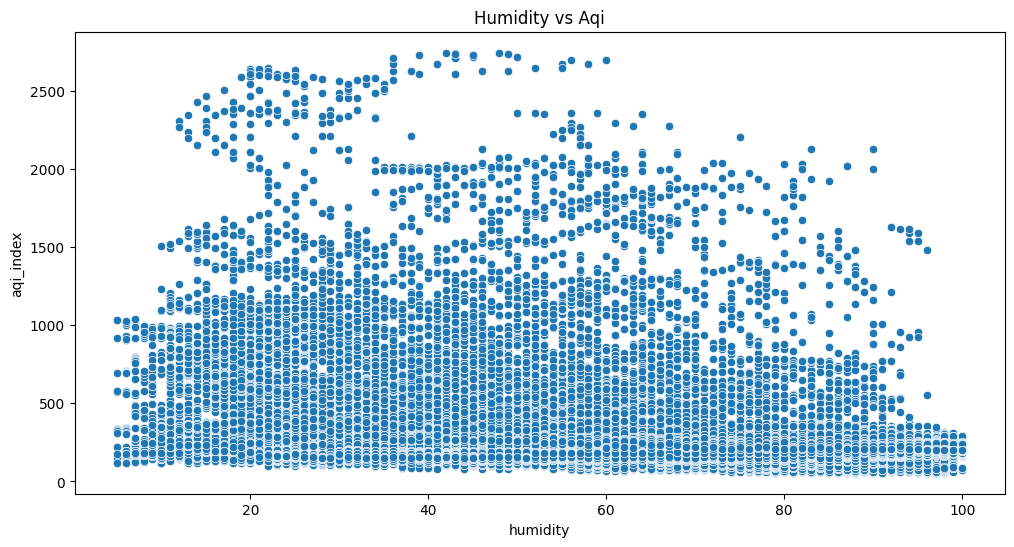

In [7]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='humidity',y='aqi_index',data=df)
plt.title("Humidity vs Aqi")
plt.show()

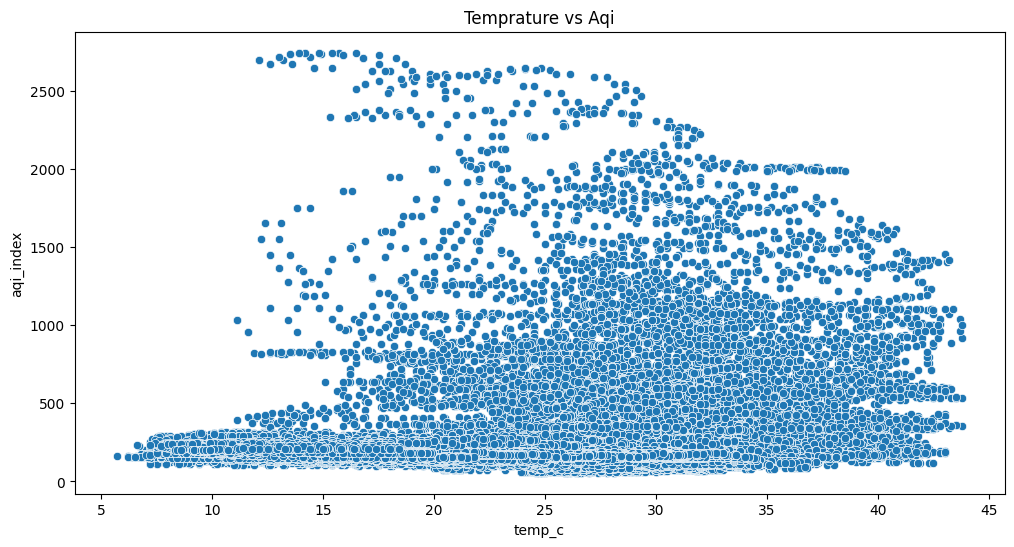

In [8]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='temp_c',y='aqi_index',data=df)
plt.title("Temprature vs Aqi")
plt.show()

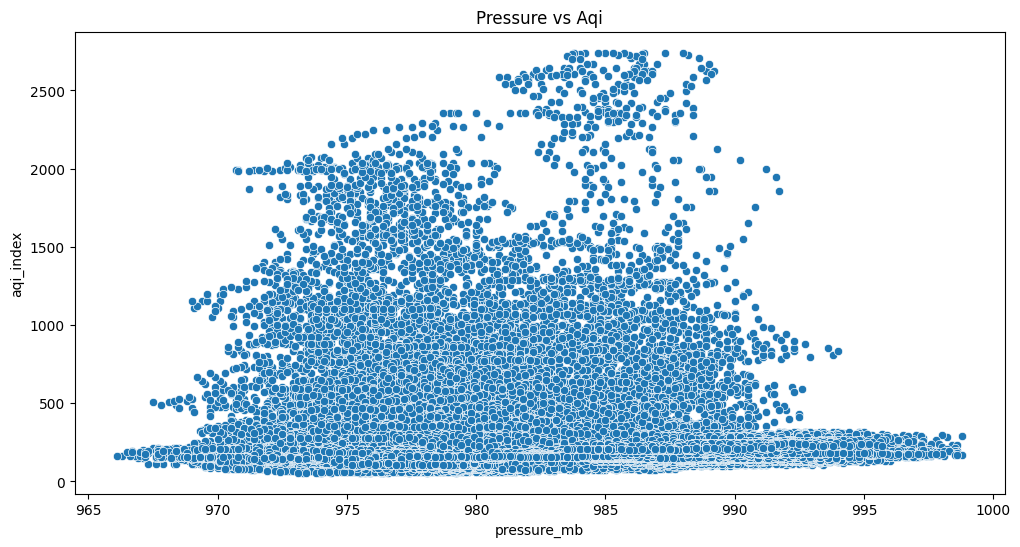

In [9]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='pressure_mb',y='aqi_index',data=df)
plt.title("Pressure vs Aqi")
plt.show()

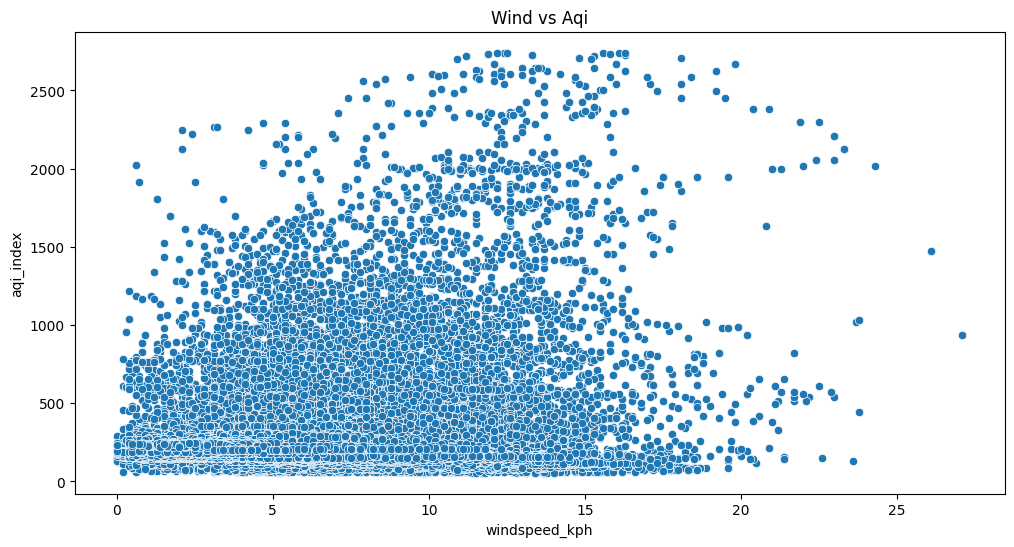

In [10]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='windspeed_kph',y='aqi_index',data=df)
plt.title("Wind vs Aqi")
plt.show()

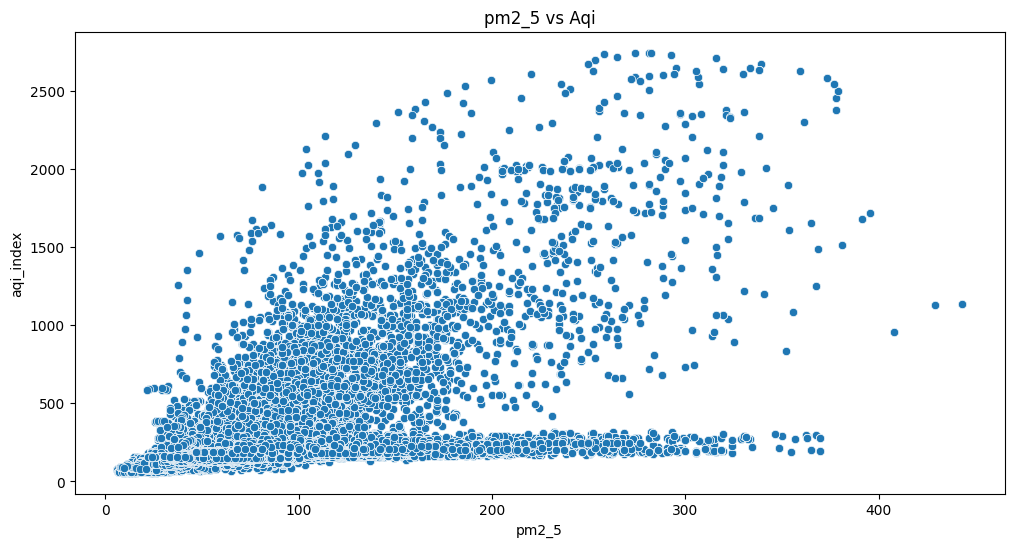

In [11]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='pm2_5',y='aqi_index',data=df)
plt.title("pm2_5 vs Aqi")
plt.show()

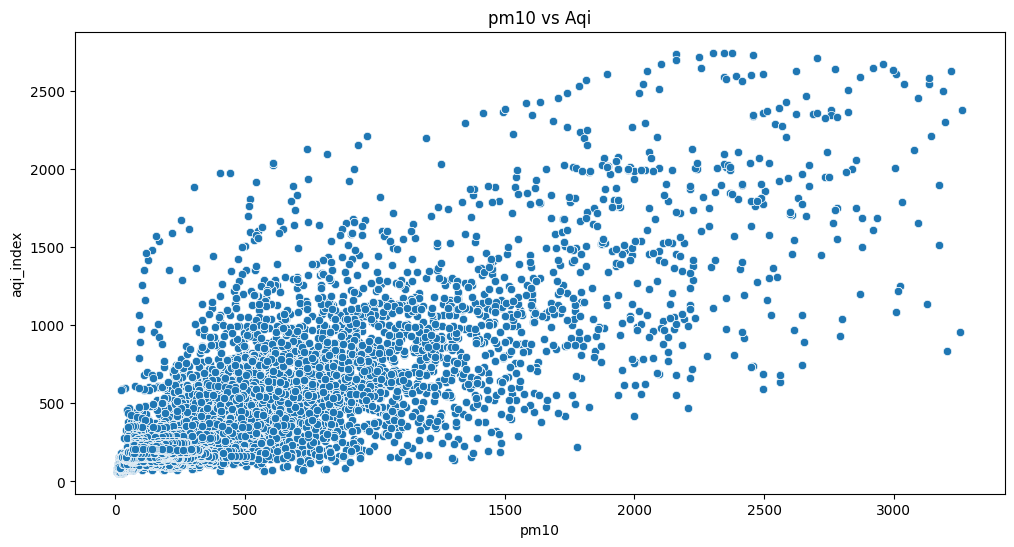

In [12]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='pm10',y='aqi_index',data=df)
plt.title("pm10 vs Aqi")
plt.show()

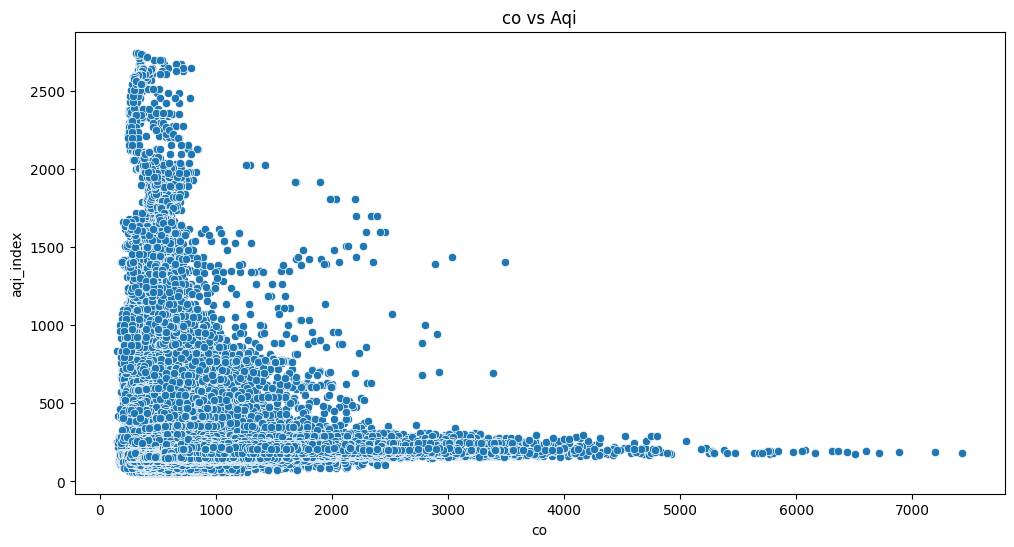

In [13]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='co',y='aqi_index',data=df)
plt.title("co vs Aqi")
plt.show()

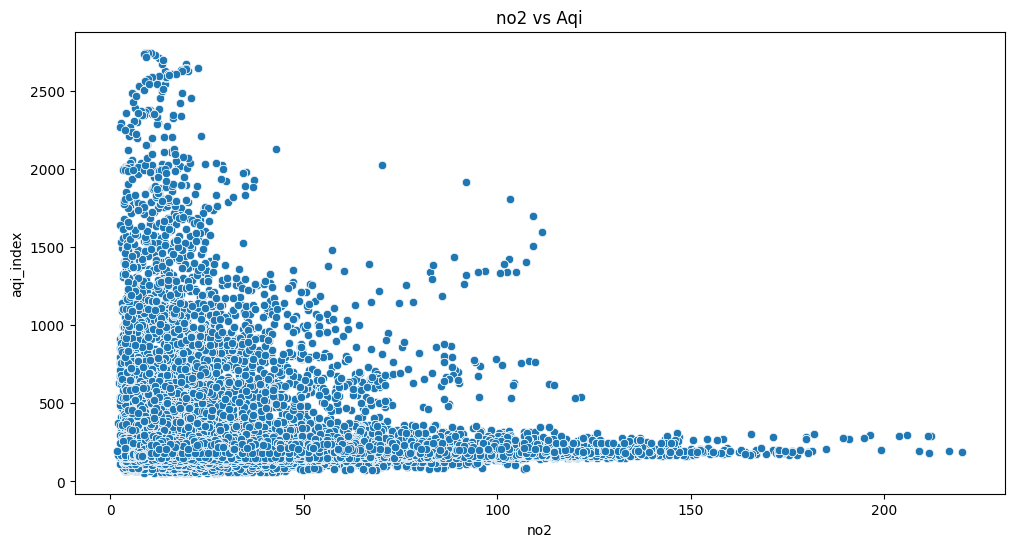

In [14]:
fig=plt.figure(figsize=(12,6))
sns.scatterplot(x='no2',y='aqi_index',data=df)
plt.title("no2 vs Aqi")
plt.show()

Checking Correlation

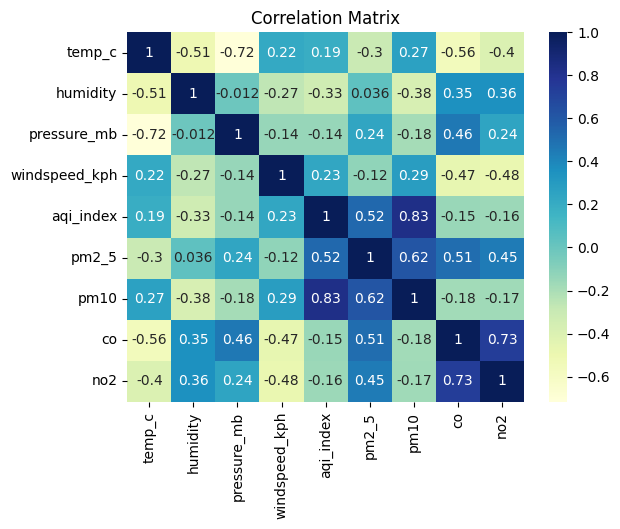

In [15]:
sns.heatmap(df[["temp_c","humidity","pressure_mb","windspeed_kph","aqi_index","pm2_5","pm10","co","no2"]].corr(),annot=True,cmap="YlGnBu")
plt.title("Correlation Matrix")
plt.show()

Converting two columns date_ist and time_ist into timestamp for datetime dataype for further use in Time Series Forcasting

In [16]:
df["timestamp"]=pd.to_datetime(df["date_ist"]+''+df["time_ist"],format="%d/%m/%Y%H:%M")
df["timestamp"]

0       2025-01-01 00:00:00
1       2025-01-01 01:00:00
2       2025-01-01 02:00:00
3       2025-01-01 03:00:00
4       2025-01-01 04:00:00
                ...        
52555   2025-12-31 19:00:00
52556   2025-12-31 20:00:00
52557   2025-12-31 21:00:00
52558   2025-12-31 22:00:00
52559   2025-12-31 23:00:00
Name: timestamp, Length: 52560, dtype: datetime64[ns]

Adding timestamp column in dataframe while removing those two

In [17]:
df.drop(columns=["date_ist","time_ist"],inplace=True)
df.set_index("timestamp",inplace=True)
df.reset_index(inplace=True)


Extracting the Hourly ,Weekly and monthly featured data

In [18]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.weekday      
df["month"] = df["timestamp"].dt.month
df["is_weekend"] = (df["weekday"] >= 5).astype(int)


Cycling the Hourly and Monthly Data

In [19]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


Giving this dataset some memory about past data 

Encoding catogorical condition_text with one hot encoder

In [20]:
condition_text=df[["condition_text"]]
encoder = OneHotEncoder( drop=None, sparse_output=False,handle_unknown="ignore")
condition_encoded = encoder.fit_transform(df[["condition_text"]])

condition_df = pd.DataFrame(
    condition_encoded,
    columns=encoder.get_feature_names_out(["condition_text"]),
    index=df.index
)


df = pd.concat(
    [df.drop(columns=["condition_text"]), condition_df],
    axis=1
)


Same for description

In [21]:
descr= encoder.fit_transform(df[["description"]])
descr_df = pd.DataFrame(
    descr,
    columns=encoder.get_feature_names_out(["description"]),
    index=df.index)

df = pd.concat(
    [df.drop(columns=["description"]), descr_df],
    axis=1
)
print(df.filter(like="description").columns)


Index(['description_WMO Code 0', 'description_WMO Code 1',
       'description_WMO Code 2', 'description_WMO Code 3',
       'description_WMO Code 45', 'description_WMO Code 51',
       'description_WMO Code 53', 'description_WMO Code 55',
       'description_WMO Code 61', 'description_WMO Code 63',
       'description_WMO Code 65'],
      dtype='object')


Checking the columns

In [22]:
for i, col in enumerate(df.columns):
    print(f"{i:02d} -> {col}")


00 -> timestamp
01 -> location
02 -> lat
03 -> lon
04 -> temp_c
05 -> humidity
06 -> pressure_mb
07 -> windspeed_kph
08 -> aqi_index
09 -> pm2_5
10 -> pm10
11 -> co
12 -> no2
13 -> hour
14 -> weekday
15 -> month
16 -> is_weekend
17 -> hour_sin
18 -> hour_cos
19 -> month_sin
20 -> month_cos
21 -> condition_text_Clear sky
22 -> condition_text_Drizzle: Dense
23 -> condition_text_Drizzle: Light
24 -> condition_text_Drizzle: Moderate
25 -> condition_text_Fog
26 -> condition_text_Mainly clear
27 -> condition_text_Overcast
28 -> condition_text_Partly cloudy
29 -> condition_text_Rain: Heavy
30 -> condition_text_Rain: Moderate
31 -> condition_text_Rain: Slight
32 -> description_WMO Code 0
33 -> description_WMO Code 1
34 -> description_WMO Code 2
35 -> description_WMO Code 3
36 -> description_WMO Code 45
37 -> description_WMO Code 51
38 -> description_WMO Code 53
39 -> description_WMO Code 55
40 -> description_WMO Code 61
41 -> description_WMO Code 63
42 -> description_WMO Code 65


In [23]:
df.head()

,timestamp,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,...,description_WMO Code 1,description_WMO Code 2,description_WMO Code 3,description_WMO Code 45,description_WMO Code 51,description_WMO Code 53,description_WMO Code 55,description_WMO Code 61,description_WMO Code 63,description_WMO Code 65
0,2025-01-01,Anand Vihar,28.6469,77.3160,8.1,100,995.4,2.9,197,185.8,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-01-01,Okhla Phase III,28.5273,77.2618,8.6,100,992.4,4.1,197,193.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-01-01,Dwarka,28.5882,77.0494,8.0,100,994.4,2.8,197,193.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-01-01,IGI Airport,28.5562,77.1000,8.0,100,991.6,2.8,197,193.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-01-01,Connaught Place,28.6304,77.2177,8.2,100,993.8,1.8,197,185.8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Saving the Processed data

In [24]:
df_processed=df.copy()
df_processed.to_csv("Aqi_delhi_processed_2025.csv", index=False)


Finding total no of locations 

In [25]:
location=df["location"]

location.unique()

array(['Anand Vihar', 'Okhla Phase III', 'Dwarka', 'IGI Airport',
       'Connaught Place', 'Rohini'], dtype=object)

In [26]:
indices_IGIAirport=df[df["location"]=="IGI Airport"].index

indices_AnandVihar=df[df["location"]=="Anand Vihar"].index

indices_ConnaughtPlace=df[df["location"]=="Connaught Place"].index

indices_Dwarka=df[df["location"]=="Dwarka"].index

indices_Okhla=df[df["location"]=="Okhla Phase III"].index

indices_Rohini=df[df["location"]=="Rohini"].index

seprating data by there location for better accuracy

In [27]:
AnandVihar=df.loc[indices_AnandVihar]
IGIAirport=df.loc[indices_IGIAirport]
ConnaughtPlace=df.loc[indices_ConnaughtPlace]
Dwarka=df.loc[indices_Dwarka]
Okhla=df.loc[indices_Okhla]
Rohini=df.loc[indices_Rohini]



In [28]:
AnandVihar.head()

,timestamp,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,...,description_WMO Code 1,description_WMO Code 2,description_WMO Code 3,description_WMO Code 45,description_WMO Code 51,description_WMO Code 53,description_WMO Code 55,description_WMO Code 61,description_WMO Code 63,description_WMO Code 65
0,2025-01-01 00:00:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,197,185.8,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2025-01-01 01:00:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,198,174.6,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2025-01-01 02:00:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,199,164.4,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,2025-01-01 03:00:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,200,156.5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2025-01-01 04:00:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,200,149.5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


droping unwanted data

In [29]:
anand=AnandVihar.drop(columns=["location","lat","lon"])

In [30]:
anand.head()

,timestamp,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2,...,description_WMO Code 1,description_WMO Code 2,description_WMO Code 3,description_WMO Code 45,description_WMO Code 51,description_WMO Code 53,description_WMO Code 55,description_WMO Code 61,description_WMO Code 63,description_WMO Code 65
0,2025-01-01 00:00:00,8.1,100,995.4,2.9,197,185.8,188.6,1907,56.7,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2025-01-01 01:00:00,7.7,100,994.7,3.2,198,174.6,177.4,1669,44.8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2025-01-01 02:00:00,7.5,100,994.3,4.5,199,164.4,166.7,1493,34.6,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,2025-01-01 03:00:00,7.8,99,994.1,6.0,200,156.5,158.8,1401,26.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2025-01-01 04:00:00,7.3,100,993.8,6.8,200,149.5,151.8,1372,20.6,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
num_cols = [
    "aqi_index", "pm2_5", "pm10", "co", "no2",
    "temp_c", "humidity", "pressure_mb", "windspeed_kph"
]

for col in num_cols:
    anand[f"{col}_lag_1"] = anand[col].shift(1)
    anand[f"{col}_lag_24"] = anand[col].shift(24)

anand["aqi_roll_24"] = anand["aqi_index"].rolling(24).mean()
anand["aqi_roll_168"] = anand["aqi_index"].rolling(168).mean()
anand.dropna(inplace=True)
anand

,timestamp,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2,...,temp_c_lag_1,temp_c_lag_24,humidity_lag_1,humidity_lag_24,pressure_mb_lag_1,pressure_mb_lag_24,windspeed_kph_lag_1,windspeed_kph_lag_24,aqi_roll_24,aqi_roll_168
1004,2025-01-07 23:00:00,11.4,91,991.8,8.7,180,104.1,105.2,891,25.0,...,11.9,11.9,92.0,94.0,992.6,993.4,8.0,9.0,189.291667,202.214286
1013,2025-01-08 00:00:00,10.8,90,991.3,9.2,179,96.9,98.0,813,20.5,...,11.4,11.6,91.0,95.0,991.8,993.1,8.7,9.5,188.625000,202.107143
1014,2025-01-08 01:00:00,10.2,89,990.6,8.7,178,90.1,91.7,734,16.4,...,10.8,11.3,90.0,96.0,991.3,992.8,9.2,10.0,187.916667,201.988095
1025,2025-01-08 02:00:00,9.8,89,990.0,9.0,177,84.3,85.9,682,13.4,...,10.2,11.0,89.0,96.0,990.6,992.6,8.7,9.9,187.166667,201.857143
1030,2025-01-08 03:00:00,9.4,89,989.7,9.6,176,79.6,81.3,655,11.4,...,9.8,10.7,89.0,97.0,990.0,992.5,9.0,9.7,186.416667,201.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52532,2025-12-31 19:00:00,14.9,86,988.0,6.7,225,169.5,170.0,1597,102.2,...,15.9,13.6,83.0,81.0,987.8,989.4,6.4,3.1,209.041667,203.196429
52537,2025-12-31 20:00:00,14.2,89,988.4,6.4,226,170.4,170.9,1698,99.1,...,14.9,12.8,86.0,87.0,988.0,989.8,6.7,3.2,209.833333,203.636905
52543,2025-12-31 21:00:00,13.6,91,988.9,5.6,228,166.7,167.6,1656,91.3,...,14.2,12.1,89.0,91.0,988.4,989.9,6.4,2.9,210.833333,204.095238
52552,2025-12-31 22:00:00,13.1,93,988.9,5.4,228,163.4,163.9,1534,79.3,...,13.6,11.6,91.0,92.0,988.9,989.8,5.6,3.3,211.958333,204.553571


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


Splitting Train,Test ans Validation data

In [33]:
anand = anand.sort_values("timestamp").reset_index(drop=True)
anand["month"] = anand["timestamp"].dt.month

train = anand[anand["month"] <= 9].copy()
test  = anand[(anand["month"] > 9) & (anand["month"] <= 12)].copy()


for df_ in [train, test]:
    df_.drop(columns=["timestamp", "month"], inplace=True)
anand.columns.unique()

Index(['timestamp', 'temp_c', 'humidity', 'pressure_mb', 'windspeed_kph',
       'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'hour', 'weekday', 'month',
       'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'condition_text_Clear sky', 'condition_text_Drizzle: Dense',
       'condition_text_Drizzle: Light', 'condition_text_Drizzle: Moderate',
       'condition_text_Fog', 'condition_text_Mainly clear',
       'condition_text_Overcast', 'condition_text_Partly cloudy',
       'condition_text_Rain: Heavy', 'condition_text_Rain: Moderate',
       'condition_text_Rain: Slight', 'description_WMO Code 0',
       'description_WMO Code 1', 'description_WMO Code 2',
       'description_WMO Code 3', 'description_WMO Code 45',
       'description_WMO Code 51', 'description_WMO Code 53',
       'description_WMO Code 55', 'description_WMO Code 61',
       'description_WMO Code 63', 'description_WMO Code 65', 'aqi_index_lag_1',
       'aqi_index_lag_24', 'pm2_5_lag_1', 'pm2_5_lag

In [34]:
y_test=test["aqi_index"]
x_test=test.drop("aqi_index",axis=1)
y_train=train["aqi_index"]
x_train=train.drop("aqi_index",axis=1)

Training data on XGBRegressor Model

In [35]:

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8
)
model.fit(x_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Predicting and calculating model accuracy

In [37]:
pred=model.predict(x_test)

In [38]:
print("MEAN_ABSOLUTE_ERROR:",mean_absolute_error(y_test,pred))

print("R2 Score:",r2_score(y_test,pred))

print("RMST:",np.sqrt(mean_squared_error(y_test, pred)))

MEAN_ABSOLUTE_ERROR: 1.5966163873672485
R2 Score: 0.9945222735404968
RMST: 2.5277832215172507


Model Visualization

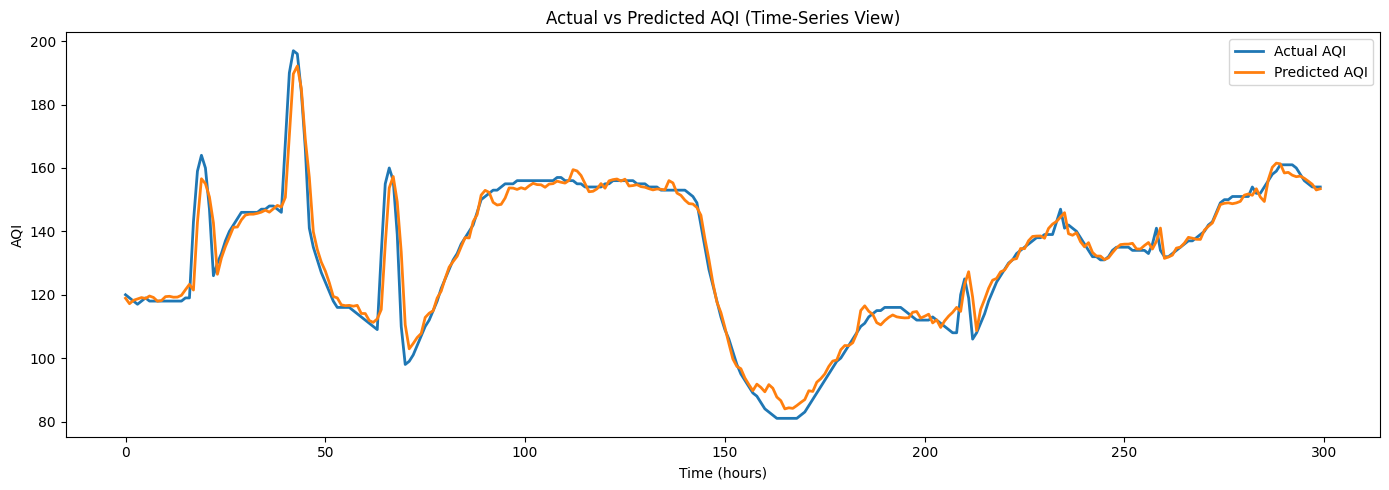

In [39]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:300], label="Actual AQI", linewidth=2)
plt.plot(pred[:300], label="Predicted AQI", linewidth=2)
plt.legend()
plt.title("Actual vs Predicted AQI (Time-Series View)")
plt.xlabel("Time (hours)")
plt.ylabel("AQI")
plt.tight_layout()
plt.savefig("Actual_vs_Predicted_AQI.jpg")
plt.show()


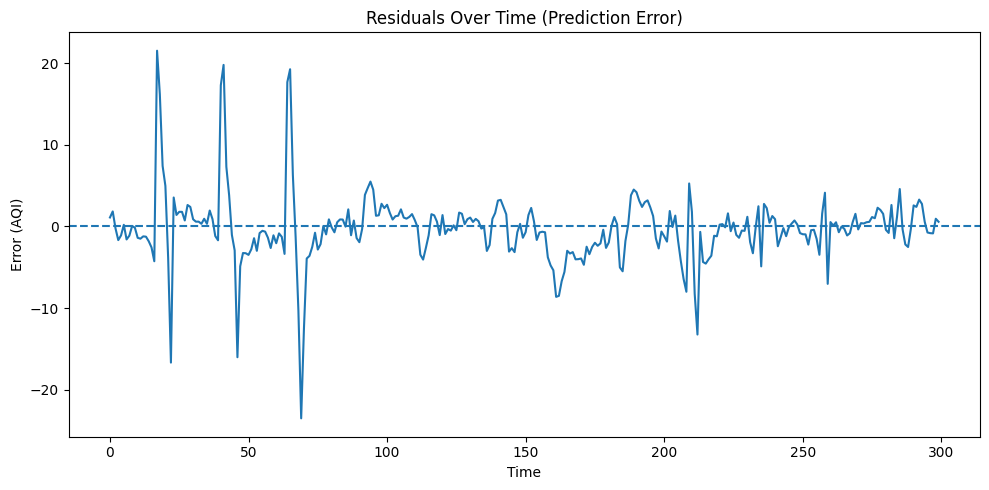

In [40]:
residuals = y_test.values - pred

plt.figure(figsize=(10,5))
plt.plot(residuals[:300])
plt.axhline(0, linestyle='--')
plt.title("Residuals Over Time (Prediction Error)")
plt.xlabel("Time")
plt.ylabel("Error (AQI)")
plt.tight_layout()
plt.show()


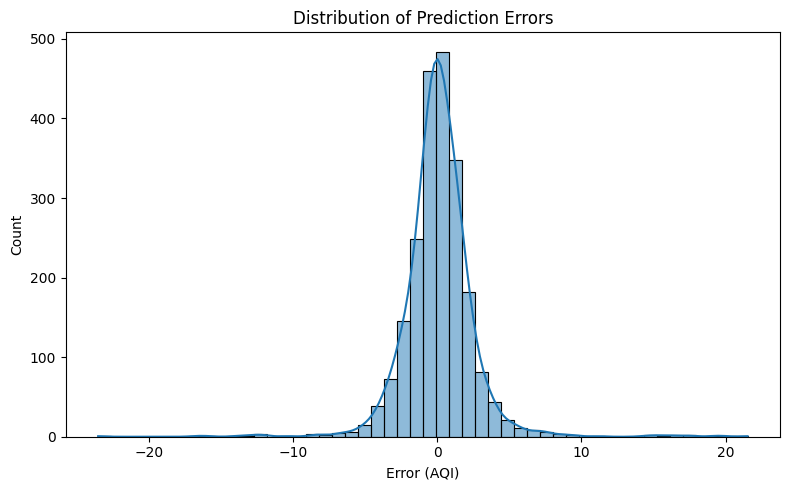

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (AQI)")
plt.tight_layout()
plt.show()


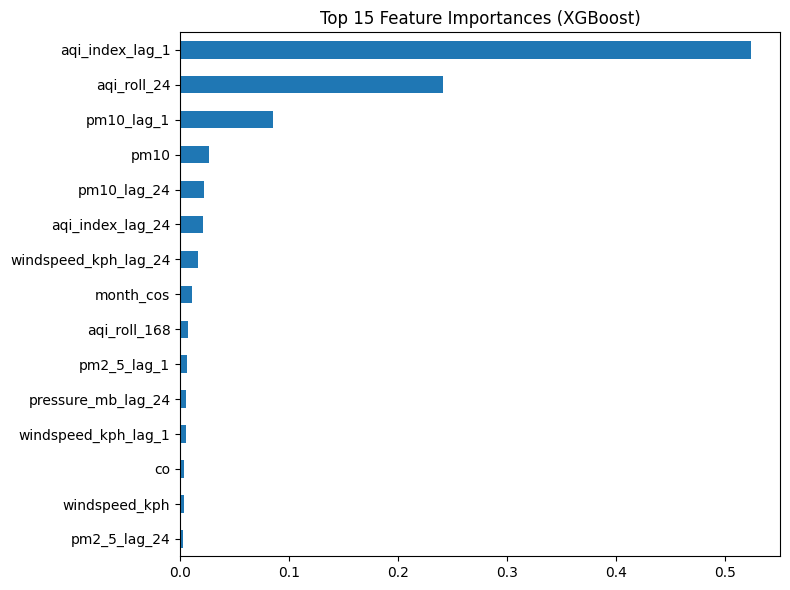

In [42]:
importance = pd.Series(
    model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(15).plot(kind="barh")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


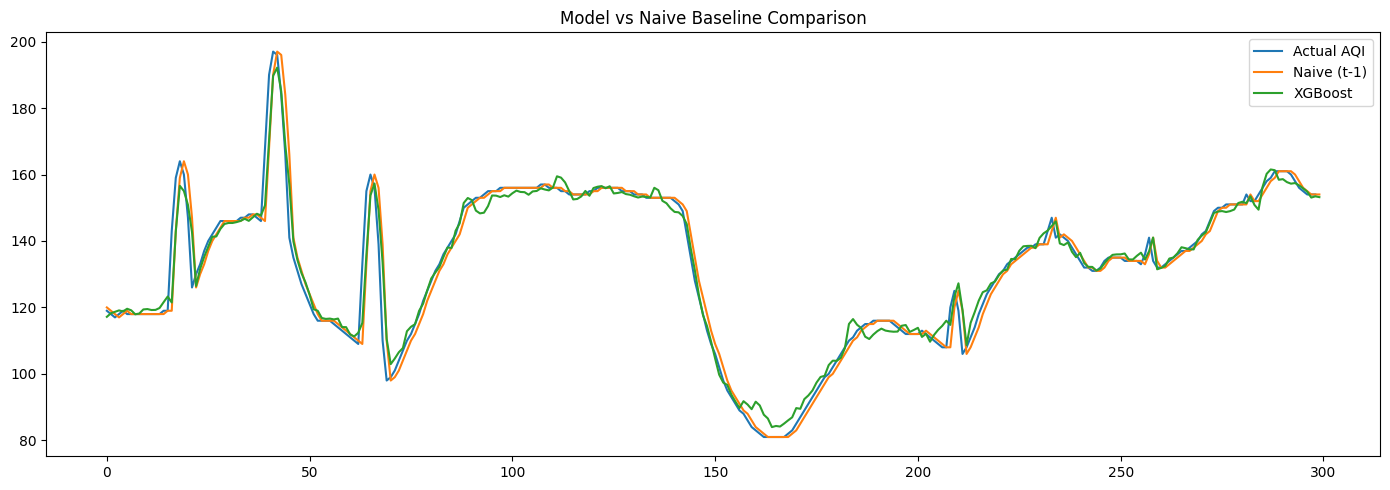

In [43]:
naive_pred = y_test.shift(1).dropna()
model_pred = pred[1:]

plt.figure(figsize=(14,5))
plt.plot(y_test.values[1:300], label="Actual AQI")
plt.plot(naive_pred.values[:300], label="Naive (t-1)")
plt.plot(model_pred[:300], label="XGBoost")
plt.legend()
plt.title("Model vs Naive Baseline Comparison")
plt.tight_layout()
plt.show()


Let's predict aqi of diffrent location

In [44]:
for col in num_cols:
    ConnaughtPlace[f"{col}_lag_1"] = ConnaughtPlace[col].shift(1)
    ConnaughtPlace[f"{col}_lag_24"] = ConnaughtPlace[col].shift(24)

ConnaughtPlace["aqi_roll_24"] = ConnaughtPlace["aqi_index"].rolling(24).mean()
ConnaughtPlace["aqi_roll_168"] = ConnaughtPlace["aqi_index"].rolling(168).mean()
ConnaughtPlace.dropna(inplace=True)
ConnaughtPlace

,timestamp,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,...,temp_c_lag_1,temp_c_lag_24,humidity_lag_1,humidity_lag_24,pressure_mb_lag_1,pressure_mb_lag_24,windspeed_kph_lag_1,windspeed_kph_lag_24,aqi_roll_24,aqi_roll_168
1005,2025-01-07 23:00:00,Connaught Place,28.6304,77.2177,11.1,90,990.5,7.9,180,104.1,...,11.6,11.9,91.0,94.0,991.1,992.0,7.3,7.6,189.291667,202.214286
1010,2025-01-08 00:00:00,Connaught Place,28.6304,77.2177,10.6,89,989.8,8.5,179,96.9,...,11.1,11.5,90.0,95.0,990.5,991.7,7.9,8.1,188.625000,202.107143
1019,2025-01-08 01:00:00,Connaught Place,28.6304,77.2177,9.8,89,989.1,7.2,178,90.1,...,10.6,11.1,89.0,95.0,989.8,991.4,8.5,8.2,187.916667,201.988095
1022,2025-01-08 02:00:00,Connaught Place,28.6304,77.2177,9.4,89,988.6,7.6,177,84.3,...,9.8,10.9,89.0,95.0,989.1,991.2,7.2,8.5,187.166667,201.857143
1026,2025-01-08 03:00:00,Connaught Place,28.6304,77.2177,9.1,89,988.2,8.3,176,79.6,...,9.4,10.6,89.0,96.0,988.6,991.0,7.6,8.4,186.416667,201.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52530,2025-12-31 19:00:00,Connaught Place,28.6304,77.2177,15.0,86,986.5,6.3,225,169.5,...,15.8,14.6,83.0,75.0,986.2,987.8,5.9,3.1,209.041667,203.196429
52540,2025-12-31 20:00:00,Connaught Place,28.6304,77.2177,14.3,89,986.9,5.8,226,170.4,...,15.0,13.7,86.0,78.0,986.5,988.3,6.3,3.1,209.833333,203.636905
52545,2025-12-31 21:00:00,Connaught Place,28.6304,77.2177,13.7,92,987.3,4.8,228,166.7,...,14.3,12.8,89.0,84.0,986.9,988.3,5.8,2.9,210.833333,204.095238
52550,2025-12-31 22:00:00,Connaught Place,28.6304,77.2177,13.2,94,987.3,4.8,228,163.4,...,13.7,12.0,92.0,89.0,987.3,988.3,4.8,3.3,211.958333,204.553571


In [45]:
ConnaughtPlace = ConnaughtPlace.drop(columns=["location","lon","lat"], axis=1)
desired_columns=[
    'temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'pm2_5', 'pm10', 'co', 'no2', 'hour', 'weekday', 'is_weekend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'condition_text_Clear sky', 'condition_text_Drizzle: Dense', 'condition_text_Drizzle: Light', 'condition_text_Drizzle: Moderate',
    'condition_text_Fog', 'condition_text_Mainly clear', 'condition_text_Overcast', 'condition_text_Partly cloudy',
    'condition_text_Rain: Heavy', 'condition_text_Rain: Moderate', 'condition_text_Rain: Slight',
    'description_WMO Code 0', 'description_WMO Code 1', 'description_WMO Code 2', 'description_WMO Code 3',
    'description_WMO Code 45', 'description_WMO Code 51', 'description_WMO Code 53', 'description_WMO Code 55',
    'description_WMO Code 61', 'description_WMO Code 63', 'description_WMO Code 65',
    'aqi_index_lag_1', 'aqi_index_lag_24', 'pm2_5_lag_1', 'pm2_5_lag_24', 'pm10_lag_1', 'pm10_lag_24',
    'co_lag_1', 'co_lag_24', 'no2_lag_1', 'no2_lag_24', 'temp_c_lag_1', 'temp_c_lag_24',
    'humidity_lag_1', 'humidity_lag_24', 'pressure_mb_lag_1', 'pressure_mb_lag_24',
    'windspeed_kph_lag_1', 'windspeed_kph_lag_24', 'aqi_roll_24', 'aqi_roll_168','aqi_index'
]
ConnaughtPlace = ConnaughtPlace[desired_columns]


In [46]:
y_conntest = ConnaughtPlace["aqi_index"]
x_conntest = ConnaughtPlace.drop("aqi_index", axis=1)

In [47]:
pred_conn=model.predict(x_conntest)

In [48]:
print("MEAN_ABSOLUTE_ERROR:",mean_absolute_error(y_conntest,pred_conn))

print("R2 Score:",r2_score(y_conntest,pred_conn))

print("RMST:",np.sqrt(mean_squared_error(y_conntest, pred_conn)))

MEAN_ABSOLUTE_ERROR: 2.2121076583862305
R2 Score: 0.9989175200462341
RMST: 3.440358031515


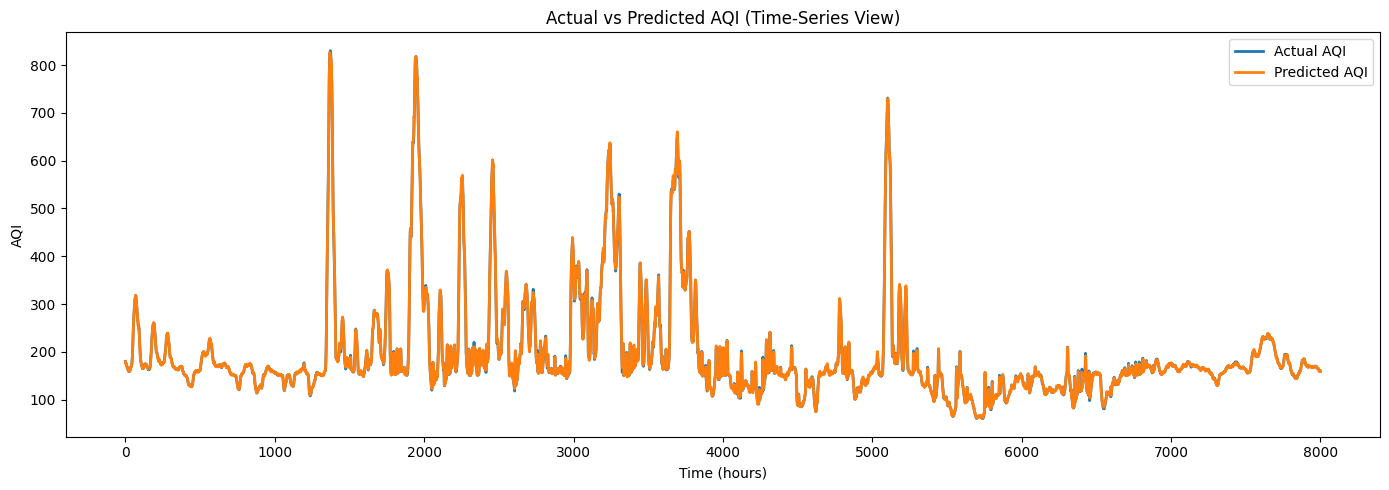

In [49]:
plt.figure(figsize=(14,5))
plt.plot(y_conntest.values[:8000], label="Actual AQI", linewidth=2)
plt.plot(pred_conn[:8000], label="Predicted AQI", linewidth=2)
plt.legend()
plt.title("Actual vs Predicted AQI (Time-Series View)")
plt.xlabel("Time (hours)")
plt.ylabel("AQI")
plt.tight_layout()
plt.savefig("Actual_vs_Predicted_AQI_ConnaughtPlace.jpg")
plt.show()


In [50]:
for col in num_cols:
    Rohini[f"{col}_lag_1"] = Rohini[col].shift(1)
    Rohini[f"{col}_lag_24"] = Rohini[col].shift(24)

Rohini["aqi_roll_24"] = Rohini["aqi_index"].rolling(24).mean()
Rohini["aqi_roll_168"] = Rohini["aqi_index"].rolling(168).mean()
Rohini.dropna(inplace=True)
Rohini

,timestamp,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,...,temp_c_lag_1,temp_c_lag_24,humidity_lag_1,humidity_lag_24,pressure_mb_lag_1,pressure_mb_lag_24,windspeed_kph_lag_1,windspeed_kph_lag_24,aqi_roll_24,aqi_roll_168
1007,2025-01-07 23:00:00,Rohini,28.7041,77.1025,10.2,93,989.9,8.5,180,104.1,...,11.1,11.6,92.0,95.0,990.7,991.5,8.8,9.5,189.291667,202.214286
1011,2025-01-08 00:00:00,Rohini,28.7041,77.1025,9.8,91,989.3,9.3,179,96.9,...,10.2,11.3,93.0,95.0,989.9,991.3,8.5,9.9,188.625000,202.107143
1015,2025-01-08 01:00:00,Rohini,28.7041,77.1025,9.3,91,988.6,8.8,178,90.1,...,9.8,10.9,91.0,96.0,989.3,991.0,9.3,10.1,187.916667,201.988095
1023,2025-01-08 02:00:00,Rohini,28.7041,77.1025,8.9,91,988.0,9.2,177,84.3,...,9.3,10.7,91.0,97.0,988.6,990.7,8.8,9.9,187.166667,201.857143
1029,2025-01-08 03:00:00,Rohini,28.7041,77.1025,8.6,91,987.8,9.6,176,79.6,...,8.9,10.4,91.0,97.0,988.0,990.6,9.2,9.4,186.416667,201.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52533,2025-12-31 19:00:00,Rohini,28.7041,77.1025,14.8,88,986.0,7.9,225,169.5,...,15.7,13.2,84.0,84.0,985.6,987.4,7.5,3.3,209.041667,203.196429
52536,2025-12-31 20:00:00,Rohini,28.7041,77.1025,14.1,90,986.3,6.8,226,170.4,...,14.8,12.3,88.0,87.0,986.0,987.8,7.9,3.9,209.833333,203.636905
52546,2025-12-31 21:00:00,Rohini,28.7041,77.1025,13.5,93,986.8,6.0,228,166.7,...,14.1,11.6,90.0,89.0,986.3,987.8,6.8,3.7,210.833333,204.095238
52549,2025-12-31 22:00:00,Rohini,28.7041,77.1025,13.1,94,986.8,6.5,228,163.4,...,13.5,10.9,93.0,92.0,986.8,987.7,6.0,3.6,211.958333,204.553571


In [51]:
Rohini = Rohini.drop(columns=["location","lon","lat"], axis=1)
Rohini = Rohini[desired_columns]

In [52]:
y_rohtest = Rohini["aqi_index"]
x_rohtest = Rohini.drop("aqi_index", axis=1)

In [53]:
pred_roh=model.predict(x_rohtest)

In [54]:
print("MEAN_ABSOLUTE_ERROR:",mean_absolute_error(y_rohtest,pred_roh))

print("R2 Score:",r2_score(y_rohtest,pred_roh))

print("RMST:",np.sqrt(mean_squared_error(y_rohtest, pred_roh)))

MEAN_ABSOLUTE_ERROR: 2.274456739425659
R2 Score: 0.9988399744033813
RMST: 3.5614846104272386


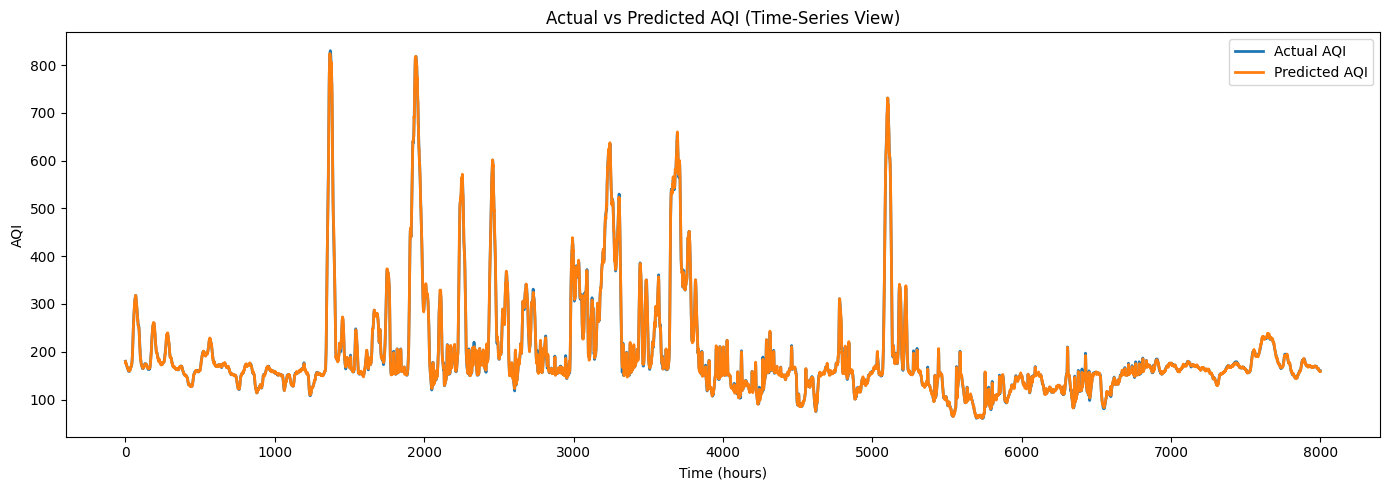

In [55]:
plt.figure(figsize=(14,5))
plt.plot(y_rohtest.values[:8000], label="Actual AQI", linewidth=2)
plt.plot(pred_roh[:8000], label="Predicted AQI", linewidth=2)
plt.legend()
plt.title("Actual vs Predicted AQI (Time-Series View)")
plt.xlabel("Time (hours)")
plt.ylabel("AQI")
plt.tight_layout()
plt.savefig("Actual_vs_Predicted_AQI_Rohini.jpg")
plt.show()


In [56]:
joblib.dump(model,'aqi_model.pkl')

['aqi_model.pkl']